# Experiment 00

Four scenarios connecting Cameroon's mines to the port of Kribi, varying:
- **Mining scope**: late-stage mines only vs. late + early-stage mines
- **Spatial mask**: no constraint vs. avoidance of protected areas

Metrics evaluated: construction cost, deforestation risk (Damania et al. 2018), and forest fragmentation (admin2-level patch analysis).

In [69]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import rasterio
from rasterio.mask import mask as rio_mask
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from IPython.display import display

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("../model/results/impact-assessment/experiment_00")
LCP_DIR       = Path("../model/results/least-cost-paths/experiment_00")
DATA_DIR      = Path("../data")
FIGURES_DIR   = BASE_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ADMIN0_FP     = DATA_DIR / "input/cmr_admin_boundaries_humdata/cmr_admin0_em.shp"
ADMIN1_FP     = DATA_DIR / "input/cmr_admin_boundaries_humdata/cmr_admin1.shp"
ADMIN2_FP     = DATA_DIR / "input/cmr_admin_boundaries_humdata/cmr_admin2.shp"
BASELINE_GPKG = DATA_DIR / "output/forest-patch-detection/no_action__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.gpkg"
MINES_FP      = DATA_DIR / "output/cmr-mine-locations/all_mines_with_id.gpkg"
ROADS_FP      = DATA_DIR / "output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg"
WDPA_DIR      = DATA_DIR / "input/WDPA_WDOECM_Mar2026_Public_CMR_shp"

# ── Scenario metadata ──────────────────────────────────────────────────────────
STEMS = [
    "late_stage__kribi__base__no_mask__ds1",
    "late_stage__kribi__base__protected_areas__ds1",
    "late_and_early_stage__kribi__base__no_mask__ds1",
    "late_and_early_stage__kribi__base__protected_areas__ds1",
]

SCENARIO_META = {
    "late_stage__kribi__base__no_mask__ds1": {
        "label": "Late-stage\nNo mask",    "short": "Late / No mask",
        "color": "#2171b5", "hatch": "",   "scope": "late", "mask": "none",
        "marker": "o",
    },
    "late_stage__kribi__base__protected_areas__ds1": {
        "label": "Late-stage\nProt. areas","short": "Late / PA",
        "color": "#6baed6", "hatch": "//", "scope": "late", "mask": "protected",
        "marker": "s",
    },
    "late_and_early_stage__kribi__base__no_mask__ds1": {
        "label": "Late+Early\nNo mask",    "short": "Late+Early / No mask",
        "color": "#d94801", "hatch": "",   "scope": "early", "mask": "none",
        "marker": "^",
    },
    "late_and_early_stage__kribi__base__protected_areas__ds1": {
        "label": "Late+Early\nProt. areas","short": "Late+Early / PA",
        "color": "#fd8d3c", "hatch": "//", "scope": "early", "mask": "protected",
        "marker": "D",
    },
}

# ── Admin boundaries ───────────────────────────────────────────────────────────
cmr0 = gpd.read_file(ADMIN0_FP).to_crs("EPSG:4326")
cmr1 = gpd.read_file(ADMIN1_FP).to_crs("EPSG:4326")
cmr2 = gpd.read_file(ADMIN2_FP).to_crs("EPSG:4326")

# ── Protected areas (WDPA) ────────────────────────────────────────────────────
_wdpa_files = sorted(glob.glob(
    str(WDPA_DIR / "**/*-polygons.shp"), recursive=True
))
wdpa = pd.concat(
    [gpd.read_file(f) for f in _wdpa_files], ignore_index=True
).to_crs("EPSG:4326")

# ── Mine locations (project-specific dataset) ─────────────────────────────────
mines_all = gpd.read_file(MINES_FP).to_crs("EPSG:4326")

# ── Existing paved roads (thin context layer) ─────────────────────────────────
_roads_raw  = gpd.read_file(ROADS_FP)
paved_roads = _roads_raw[_roads_raw["Surface"] == "paved"].to_crs("EPSG:4326")

# ── Map extent ────────────────────────────────────────────────────────────────
x0, y0, x1, y1 = cmr0.total_bounds
pad = 0.3

print(f"Setup complete — {len(mines_all)} mines, {len(paved_roads):,} paved road segments.")
print(f"Protected areas: {len(wdpa)} polygons")
print(f"Figures → {FIGURES_DIR}")

Setup complete — 44 mines, 20,706 paved road segments.
Protected areas: 53 polygons
Figures → ..\model\results\impact-assessment\experiment_00\figures


In [70]:
# ── Load and concatenate all 4 assessment CSVs ────────────────────────────────
dfs = []
for stem in STEMS:
    df = pd.read_csv(BASE_DIR / f"{stem}__assessment.csv")
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

for col in ["label", "short", "color", "hatch", "scope", "mask"]:
    all_df[col] = all_df["scenario"].map(lambda s, c=col: SCENARIO_META[s][c])

print(f"Loaded {len(all_df)} scenarios × {len(all_df.columns)} columns\n")

# ── Summary table ──────────────────────────────────────────────────────────────
SUMMARY_COLS = {
    "short":                   "Scenario",
    "paved_km":                "Paved km",
    "unpaved_km":              "Unpaved km",
    "to_be_built_km":          "New-build km",
    "total_km":                "Total km",
    "total_cost_usd":          "Total cost (USD)",
    "upgrade_cost_usd":        "Upgrade cost (USD)",
    "new_build_cost_usd":      "New-build cost (USD)",
    "defor_action_ha":         "Deforestation (ha)",
    "defor_upgrade_ha":        "Defor.–upgrade (ha)",
    "defor_build_ha":          "Defor.–build (ha)",
    "frag_delta_n_patches":    "Δ patches",
    "frag_delta_mean_patch_ha":"Δ mean patch (ha)",
    "frag_delta_frag_index":   "Δ frag. index",
}

summary = (
    all_df[list(SUMMARY_COLS)]
    .rename(columns=SUMMARY_COLS)
    .set_index("Scenario")
)

display(
    summary.style
    .format({
        "Paved km":              "{:.0f}",
        "Unpaved km":            "{:.0f}",
        "New-build km":          "{:.1f}",
        "Total km":              "{:.0f}",
        "Total cost (USD)":      "${:,.0f}",
        "Upgrade cost (USD)":    "${:,.0f}",
        "New-build cost (USD)":  "${:,.0f}",
        "Deforestation (ha)":    "{:,.0f}",
        "Defor.–upgrade (ha)":   "{:,.0f}",
        "Defor.–build (ha)":     "{:,.0f}",
        "Δ patches":             "{:+.0f}",
        "Δ mean patch (ha)":     "{:+.2f}",
        "Δ frag. index":         "{:+.2e}",
    })
    .background_gradient(
        subset=["Total cost (USD)", "Deforestation (ha)", "Δ patches"],
        cmap="YlOrRd",
    )
    .set_caption("All 4 scenarios — key impact metrics")
)

Loaded 4 scenarios × 81 columns



,Paved km,Unpaved km,New-build km,Total km,Total cost (USD),Upgrade cost (USD),New-build cost (USD),Deforestation (ha),Defor.–upgrade (ha),Defor.–build (ha),Δ patches,Δ mean patch (ha),Δ frag. index
Scenario,,,,,,,,,,,,,
Late / No mask,2766,166,31.1,2963,"$93,843,064","$62,048,984","$31,794,080","41,689","28,123","13,566",+3,-0.28,+2.10e-07
Late / PA,2743,189,47.0,2979,"$116,139,112","$71,176,752","$44,962,360","44,130","28,994","15,136",+24,-1.22,+8.90e-07
Late+Early / No mask,3865,256,79.8,4201,"$174,322,712","$93,278,656","$81,044,056","67,164","41,529","25,635",+66,-3.13,+2.28e-06
Late+Early / PA,4035,279,96.1,4410,"$196,872,200","$102,406,400","$94,465,800","70,086","42,400","27,687",+105,-4.86,+3.55e-06


## 0. AS-IS Analysis — Cameroon Background

Baseline context for Cameroon: existing infrastructure, protected areas, mine locations,
and pre-road forest fragmentation state.

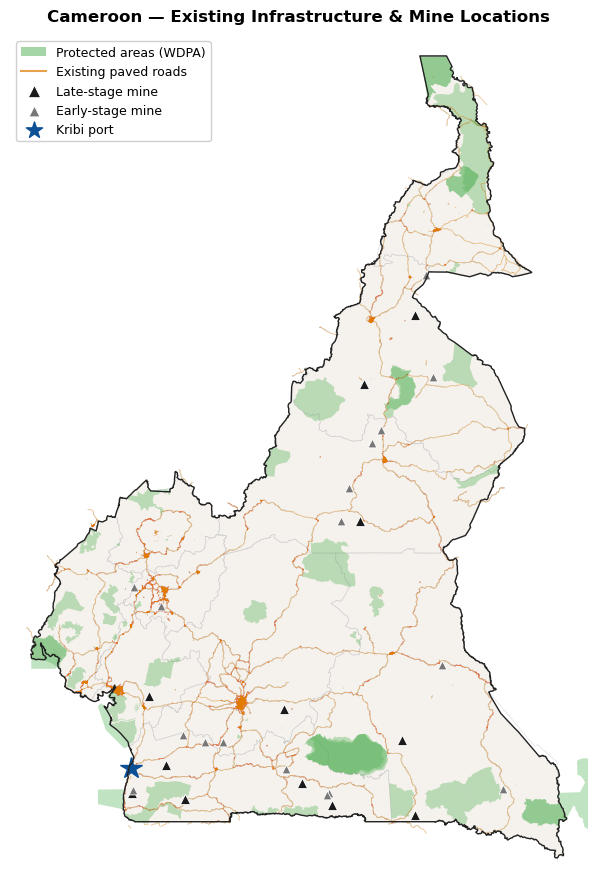

In [71]:
# ── Context map: protected areas + paved roads + mine locations ───────────────
fig, ax = plt.subplots(figsize=(7, 9))

# Country fill + admin1 borders
cmr0.plot(ax=ax, color="#f5f1ec", edgecolor="none", zorder=1)
cmr1.plot(ax=ax, color="none",    edgecolor="#ccc", linewidth=0.3, zorder=2)

# Protected areas (green)
wdpa.plot(ax=ax, color="#4caf50", alpha=0.35, edgecolor="none", zorder=3)

# Existing paved roads (amber thin)
paved_roads.plot(ax=ax, color="#e07b00", linewidth=0.5, alpha=0.5, zorder=4)

# Mine locations by stage
late_mines  = mines_all[mines_all["DEV_STAGE_AGGREGATED_SNL"] == "Late-stage"]
early_mines = mines_all[mines_all["DEV_STAGE_AGGREGATED_SNL"] == "Early-stage"]
if not late_mines.empty:
    late_mines.plot(ax=ax, marker="^", color="#1a1a1a", markersize=55,
                    edgecolor="white", linewidth=0.7, zorder=6)
if not early_mines.empty:
    early_mines.plot(ax=ax, marker="^", color="#777", markersize=40,
                     edgecolor="white", linewidth=0.6, zorder=6)

# Kribi port
ax.plot(9.9278, 2.9408, marker="*", color="#0c5096", markersize=16, zorder=7)

# Country outline
cmr0.plot(ax=ax, color="none", edgecolor="#222", linewidth=1.0, zorder=8)

ax.set_xlim(x0 - pad, x1 + pad)
ax.set_ylim(y0 - pad, y1 + pad)
ax.axis("off")
ax.set_title("Cameroon — Existing Infrastructure & Mine Locations",
             fontweight="bold", fontsize=12, pad=10)

# Legend
legend_handles = [
    mpatches.Patch(facecolor="#4caf50", alpha=0.5, label="Protected areas (WDPA)"),
    mlines.Line2D([], [], color="#e07b00", linewidth=1.5, alpha=0.7, label="Existing paved roads"),
    plt.scatter([], [], marker="^", color="#1a1a1a", s=80,
                edgecolors="white", linewidth=0.7, label="Late-stage mine"),
    plt.scatter([], [], marker="^", color="#777", s=60,
                edgecolors="white", linewidth=0.6, label="Early-stage mine"),
    plt.scatter([], [], marker="*", color="#0c5096", s=150, label="Kribi port"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
          frameon=True, framealpha=0.92)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig0a_context_map.png", dpi=150, bbox_inches="tight")
plt.show()

Loaded baseline fragmentation for 58 admin2 units.


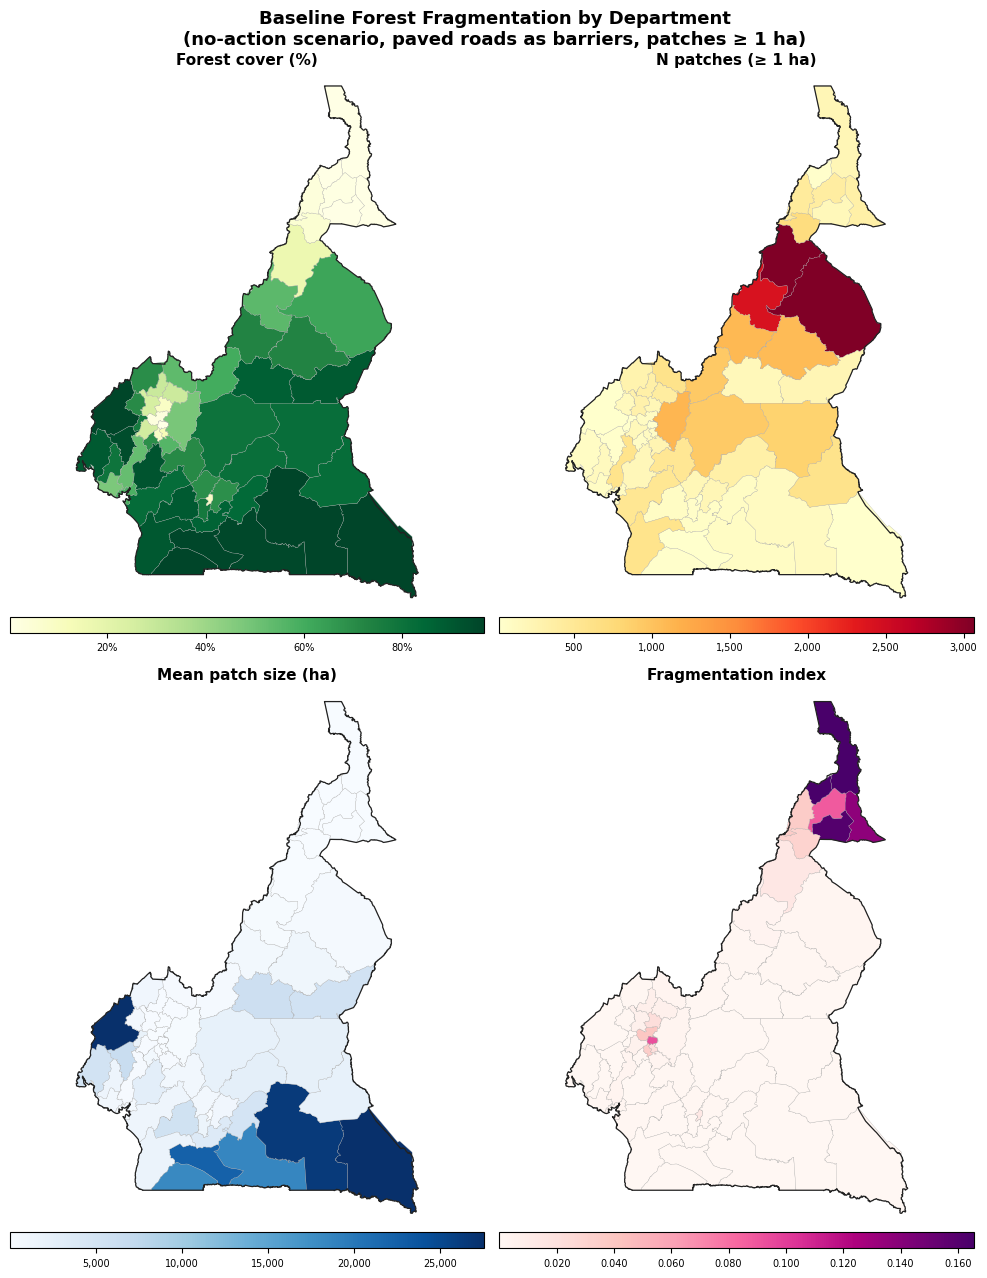

In [72]:
# ── Baseline forest fragmentation — admin2 choropleth ─────────────────────────
baseline_frag = (
    gpd.read_file(BASELINE_GPKG)
    .to_crs("EPSG:4326")
    [["adm2_name1", "adm1_name1", "area_ha", "forest_ha",
      "pct_forest", "n_patches", "mean_patch_ha", "frag_index", "geometry"]]
    .rename(columns={"adm2_name1": "department", "adm1_name1": "region"})
)
print(f"Loaded baseline fragmentation for {len(baseline_frag)} admin2 units.")

PANEL_SPECS_BL = [
    ("pct_forest",    "Forest cover (%)",            "YlGn",  "{:.0f}%"),
    ("n_patches",     "N patches (≥ 1 ha)",          "YlOrRd","{:,.0f}"),
    ("mean_patch_ha", "Mean patch size (ha)",         "Blues", "{:,.0f}"),
    ("frag_index",    "Fragmentation index",          "RdPu",  "{:.3f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 13))
fig.suptitle(
    "Baseline Forest Fragmentation by Department\n"
    "(no-action scenario, paved roads as barriers, patches ≥ 1 ha)",
    fontsize=13, fontweight="bold",
)

for ax, (col, title, cmap_name, fmt) in zip(axes.flat, PANEL_SPECS_BL):
    vmin = baseline_frag[col].quantile(0.02)
    vmax = baseline_frag[col].quantile(0.98)
    norm = Normalize(vmin=vmin, vmax=vmax)

    cmr0.plot(ax=ax, color="#f5f1ec", edgecolor="none", zorder=1)
    baseline_frag.plot(column=col, ax=ax, cmap=cmap_name, norm=norm,
                       edgecolor="#aaa", linewidth=0.2, legend=False, zorder=2)
    cmr0.plot(ax=ax, color="none", edgecolor="#222", linewidth=0.9, zorder=3)

    sm = ScalarMappable(cmap=cmap_name, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, orientation="horizontal",
                      fraction=0.04, pad=0.01, aspect=30)
    cb.ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _, f=fmt: f.format(x))
    )
    cb.ax.tick_params(labelsize=7)

    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig0b_baseline_fragmentation.png", dpi=150, bbox_inches="tight")
plt.show()

## 1. Spatial Map — Action Roads

All four scenarios overlaid on admin1 boundaries. Orange = road upgrades (unpaved → paved);
red = new construction. Mine locations from the SSA mining dataset are shown as triangles.

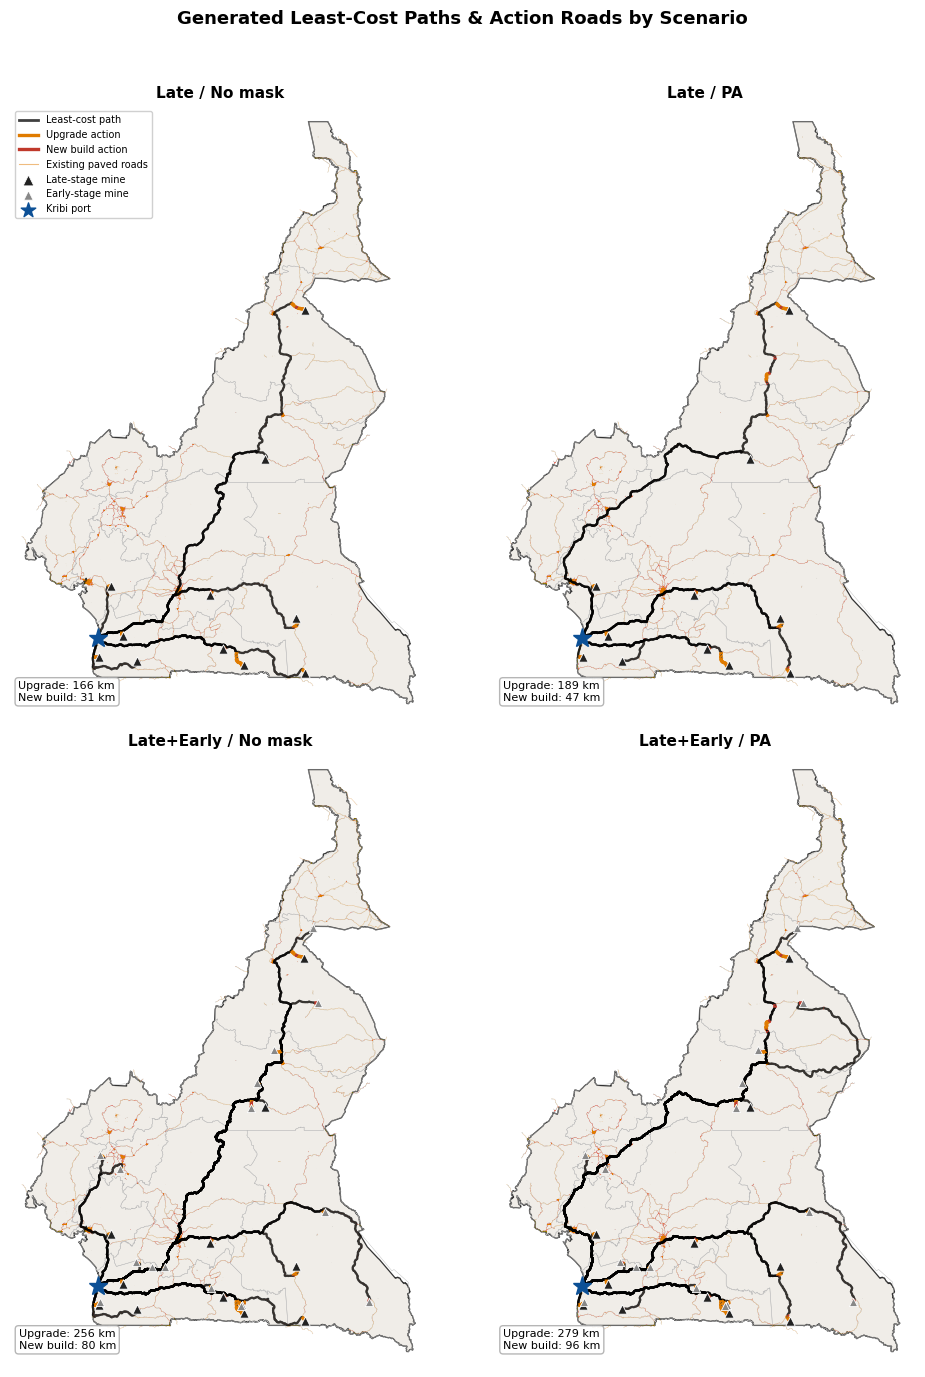

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(10, 14))
fig.suptitle("Generated Least-Cost Paths & Action Roads by Scenario",
             fontsize=13, fontweight="bold")

for ax, stem in zip(axes.flat, STEMS):
    meta  = SCENARIO_META[stem]
    roads = gpd.read_file(BASE_DIR / f"{stem}__action_roads.gpkg").to_crs("EPSG:4326")
    lcp   = gpd.read_file(LCP_DIR / f"{stem}.gpkg").to_crs("EPSG:4326")

    # Background
    cmr0.plot(ax=ax, color="#f0ede8", edgecolor="#333", linewidth=0.9, zorder=1)
    cmr1.plot(ax=ax, color="none",    edgecolor="#bbb", linewidth=0.3, zorder=2)

    # Existing paved roads — thin context
    paved_roads.plot(ax=ax, color="#e07b00", linewidth=0.4, alpha=0.35, zorder=3)

    # Least-cost paths — uniform black for all scenarios
    lcp.plot(ax=ax, color="black", linewidth=1.6, alpha=0.75, zorder=4)

    # Action roads — colored on top
    upgrades  = roads[roads["action_needed"] == "upgrade"]
    new_roads = roads[roads["action_needed"] == "build"]
    if not upgrades.empty:
        upgrades.plot(ax=ax,  color="#e07b00", linewidth=2.4, zorder=5)
    if not new_roads.empty:
        new_roads.plot(ax=ax, color="#c0392b", linewidth=2.4, zorder=5)

    # Mine locations
    mine_ids_in_scen = set(roads["mine_id"].unique())
    mines_scen = mines_all[mines_all["ID"].isin(mine_ids_in_scen)]
    late_m  = mines_scen[mines_scen["DEV_STAGE_AGGREGATED_SNL"] == "Late-stage"]
    early_m = mines_scen[mines_scen["DEV_STAGE_AGGREGATED_SNL"] == "Early-stage"]
    if not late_m.empty:
        late_m.plot(ax=ax, marker="^", color="#222", markersize=45,
                    edgecolor="white", linewidth=0.6, zorder=7)
    if not early_m.empty:
        early_m.plot(ax=ax, marker="^", color="#888", markersize=35,
                     edgecolor="white", linewidth=0.6, zorder=7)

    ax.plot(9.9278, 2.9408, marker="*", color="#0c5096", markersize=14, zorder=8)

    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)
    ax.axis("off")
    ax.set_title(meta["short"], fontweight="bold", fontsize=11)

    up_km  = all_df.loc[all_df["scenario"] == stem, "unpaved_km"].values[0]
    bld_km = all_df.loc[all_df["scenario"] == stem, "to_be_built_km"].values[0]
    ax.text(0.02, 0.03,
            f"Upgrade: {up_km:.0f} km\nNew build: {bld_km:.0f} km",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85, ec="#aaa"))

legend_handles = [
    mlines.Line2D([], [], color="black", linewidth=2, alpha=0.75, label="Least-cost path"),
    mlines.Line2D([], [], color="#e07b00", linewidth=2.4, label="Upgrade action"),
    mlines.Line2D([], [], color="#c0392b", linewidth=2.4, label="New build action"),
    mlines.Line2D([], [], color="#e07b00", linewidth=0.8, alpha=0.5, label="Existing paved roads"),
    plt.scatter([], [], marker="^", color="#222", s=60, edgecolors="white",
                linewidth=0.6, label="Late-stage mine"),
    plt.scatter([], [], marker="^", color="#888", s=45, edgecolors="white",
                linewidth=0.6, label="Early-stage mine"),
    plt.scatter([], [], marker="*", color="#0c5096", s=120, label="Kribi port"),
]
axes[0, 0].legend(handles=legend_handles, loc="upper left", fontsize=7,
                  frameon=True, framealpha=0.92)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / "fig1_action_roads_map.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

## 2. Scenario Comparison Bar Charts

Side-by-side comparison of all four scenarios across the four key impact dimensions.

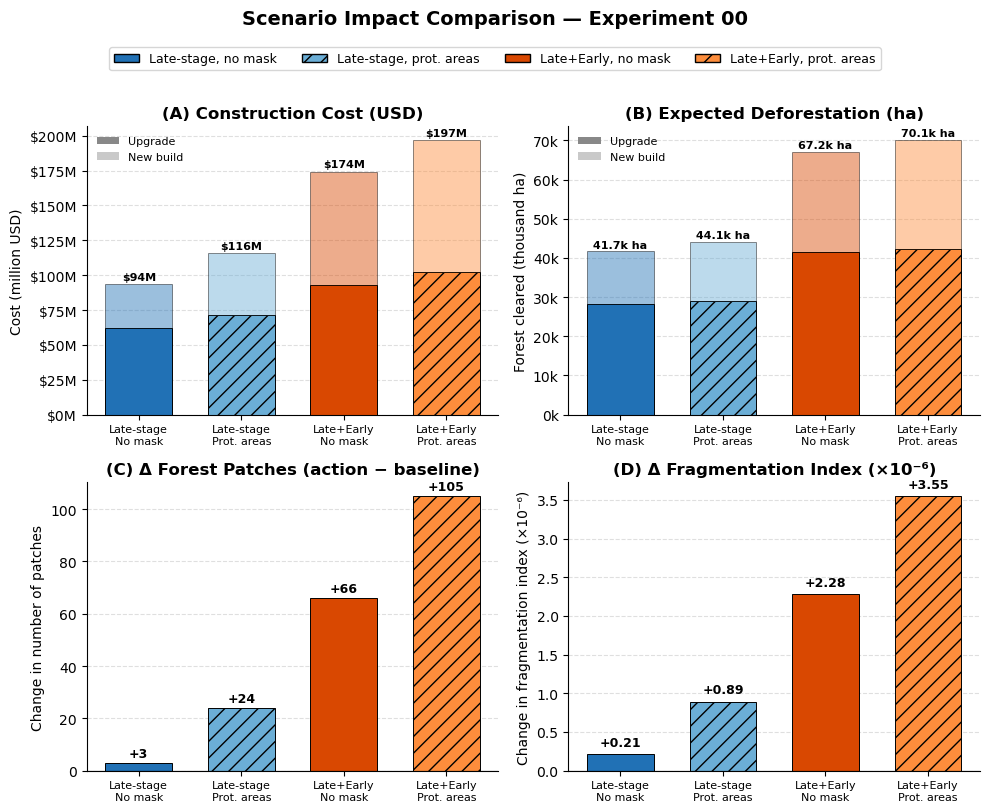

In [74]:
labels  = [SCENARIO_META[s]["label"]  for s in STEMS]
colors  = [SCENARIO_META[s]["color"]  for s in STEMS]
hatches = [SCENARIO_META[s]["hatch"]  for s in STEMS]
x       = np.arange(len(STEMS))
w       = 0.65

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Scenario Impact Comparison — Experiment 00", fontsize=14, fontweight="bold", y=1.01)

# ── (A) Construction cost ─────────────────────────────────────────────────────
ax = axes[0, 0]
vals_u = all_df["upgrade_cost_usd"].values / 1e6
vals_b = all_df["new_build_cost_usd"].values / 1e6
ax.bar(x, vals_u, w, color=colors, edgecolor="black", linewidth=0.7, hatch=hatches)
ax.bar(x, vals_b, w, bottom=vals_u, color=colors, edgecolor="black", linewidth=0.7, alpha=0.45)
for i, (u, b) in enumerate(zip(vals_u, vals_b)):
    ax.text(i, u + b + 1.5, f"${u+b:.0f}M", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("(A) Construction Cost (USD)", fontweight="bold")
ax.set_ylabel("Cost (million USD)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
ax.legend(handles=[
    mpatches.Patch(facecolor="#888", label="Upgrade"),
    mpatches.Patch(facecolor="#888", alpha=0.45, label="New build"),
], fontsize=8, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── (B) Deforestation ─────────────────────────────────────────────────────────
ax = axes[0, 1]
vals_u = all_df["defor_upgrade_ha"].values / 1e3
vals_b = all_df["defor_build_ha"].values / 1e3
ax.bar(x, vals_u, w, color=colors, edgecolor="black", linewidth=0.7, hatch=hatches)
ax.bar(x, vals_b, w, bottom=vals_u, color=colors, edgecolor="black", linewidth=0.7, alpha=0.45)
for i, (u, b) in enumerate(zip(vals_u, vals_b)):
    ax.text(i, u + b + 0.4, f"{(u+b):.1f}k ha", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_title("(B) Expected Deforestation (ha)", fontweight="bold")
ax.set_ylabel("Forest cleared (thousand ha)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k"))
ax.legend(handles=[
    mpatches.Patch(facecolor="#888", label="Upgrade"),
    mpatches.Patch(facecolor="#888", alpha=0.45, label="New build"),
], fontsize=8, frameon=False)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── (C) Δ patches ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
vals = all_df["frag_delta_n_patches"].values
ax.bar(x, vals, w, color=colors, edgecolor="black", linewidth=0.7, hatch=hatches)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"+{v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("(C) Δ Forest Patches (action − baseline)", fontweight="bold")
ax.set_ylabel("Change in number of patches")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── (D) Δ fragmentation index ─────────────────────────────────────────────────
ax = axes[1, 1]
vals = all_df["frag_delta_frag_index"].values * 1e6   # scale to ×10⁻⁶
ax.bar(x, vals, w, color=colors, edgecolor="black", linewidth=0.7, hatch=hatches)
for i, v in enumerate(vals):
    offset = abs(vals).max() * 0.02
    va = "bottom" if v >= 0 else "top"
    ax.text(i, v + (offset if v >= 0 else -offset),
            f"{v:+.2f}", ha="center", va=va, fontsize=9, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("(D) Δ Fragmentation Index (×10⁻⁶)", fontweight="bold")
ax.set_ylabel("Change in fragmentation index (×10⁻⁶)")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle="--", alpha=0.4)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor="#2171b5", edgecolor="black", label="Late-stage, no mask"),
    mpatches.Patch(facecolor="#6baed6", edgecolor="black", hatch="//", label="Late-stage, prot. areas"),
    mpatches.Patch(facecolor="#d94801", edgecolor="black", label="Late+Early, no mask"),
    mpatches.Patch(facecolor="#fd8d3c", edgecolor="black", hatch="//", label="Late+Early, prot. areas"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 0.97), fontsize=9, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIGURES_DIR / "fig2_scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

## 3. Cost–Environment Trade-offs

Two scatter plots showing how cost trades off against deforestation risk and forest
fragmentation independently. Each point is one scenario; shape encodes scenario identity.

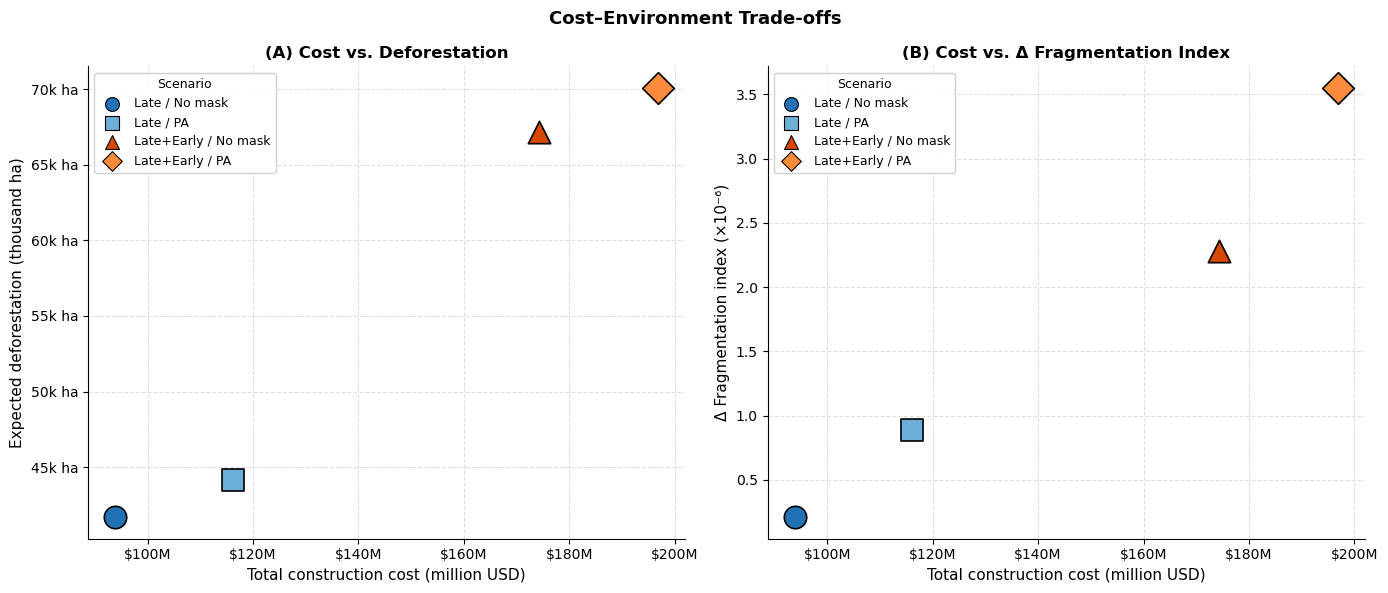

In [75]:
cost     = all_df["total_cost_usd"].values / 1e6
defor    = all_df["defor_action_ha"].values / 1e3
delta_fi = all_df["frag_delta_frag_index"].values * 1e6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Cost–Environment Trade-offs", fontsize=13, fontweight="bold")

legend_handles = []
for i, stem in enumerate(STEMS):
    meta = SCENARIO_META[stem]
    kw = dict(s=260, marker=meta["marker"], color=meta["color"],
              edgecolors="black", linewidth=1.2, zorder=5)
    ax1.scatter(cost[i], defor[i],    **kw)
    ax2.scatter(cost[i], delta_fi[i], **kw)
    legend_handles.append(
        plt.scatter([], [], marker=meta["marker"], color=meta["color"],
                    s=100, edgecolors="black", linewidth=0.8, label=meta["short"])
    )

for ax in (ax1, ax2):
    ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
              frameon=True, framealpha=0.92, title="Scenario", title_fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}M"))
    ax.set_xlabel("Total construction cost (million USD)", fontsize=11)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

ax1.set_ylabel("Expected deforestation (thousand ha)", fontsize=11)
ax1.set_title("(A) Cost vs. Deforestation", fontweight="bold")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}k ha"))

ax2.set_ylabel("Δ Fragmentation index (×10⁻⁶)", fontsize=11)
ax2.set_title("(B) Cost vs. Δ Fragmentation Index", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig3_tradeoff_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

## 4. Patch Size Distribution

How each scenario shifts the forest patch size distribution relative to the baseline.
Each panel shows action bars (scenario color) vs. baseline bars (grey).

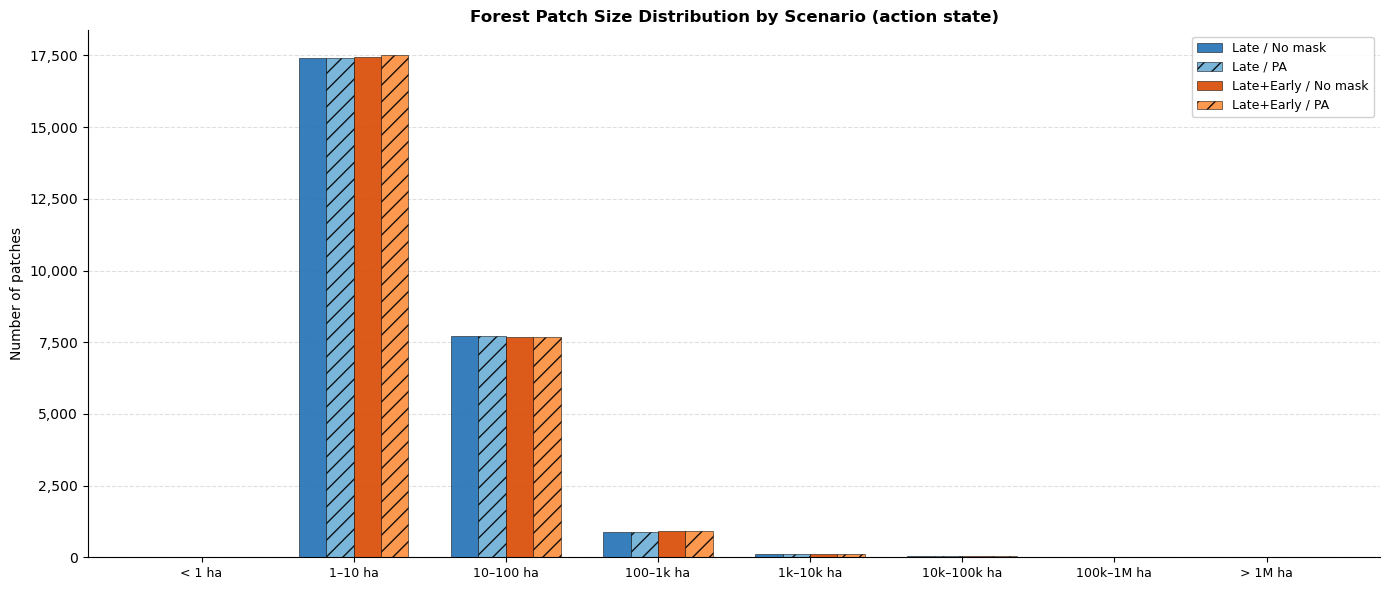

,Baseline N,Action N,ΔN,Baseline ha,Action ha,Δha
Size class,,,,,,
> 1M ha,9,9,+0,"25,628,368","25,626,097","-2,271"
100k–1M ha,15,15,+0,"5,827,211","5,811,094","-16,116"
10k–100k ha,30,31,+1,"978,949","993,750","+14,801"
1k–10k ha,118,118,+0,"334,297","334,045",-252
100–1k ha,898,897,-1,"222,936","222,534",-402
10–100 ha,"7,708","7,701",-7,"205,943","205,750",-193
1–10 ha,"17,391","17,401",+10,"72,474","72,473",-1
< 1 ha,7,7,+0,5,5,+0


,Baseline N,Action N,ΔN,Baseline ha,Action ha,Δha
Size class,,,,,,
> 1M ha,9,9,+0,"25,628,368","25,624,988","-3,380"
100k–1M ha,15,15,+0,"5,827,211","5,811,094","-16,116"
10k–100k ha,30,31,+1,"978,949","993,403","+14,454"
1k–10k ha,118,118,+0,"334,297","333,980",-317
100–1k ha,898,897,-1,"222,936","222,481",-455
10–100 ha,"7,708","7,701",-7,"205,943","205,735",-208
1–10 ha,"17,391","17,422",+31,"72,474","72,514",+40
< 1 ha,7,7,+0,5,5,+0


,Baseline N,Action N,ΔN,Baseline ha,Action ha,Δha
Size class,,,,,,
> 1M ha,9,9,+0,"25,628,368","25,622,946","-5,422"
100k–1M ha,15,15,+0,"5,827,211","5,799,821","-27,389"
10k–100k ha,30,31,+1,"978,949","992,863","+13,914"
1k–10k ha,118,120,+2,"334,297","343,748","+9,451"
100–1k ha,898,899,+1,"222,936","222,655",-281
10–100 ha,"7,708","7,697",-11,"205,943","205,674",-269
1–10 ha,"17,391","17,464",+73,"72,474","72,666",+191
< 1 ha,7,7,+0,5,5,+0


,Baseline N,Action N,ΔN,Baseline ha,Action ha,Δha
Size class,,,,,,
> 1M ha,9,9,+0,"25,628,368","25,621,312","-7,056"
100k–1M ha,15,15,+0,"5,827,211","5,799,428","-27,782"
10k–100k ha,30,31,+1,"978,949","992,516","+13,567"
1k–10k ha,118,120,+2,"334,297","343,683","+9,386"
100–1k ha,898,899,+1,"222,936","222,601",-335
10–100 ha,"7,708","7,698",-10,"205,943","205,721",-222
1–10 ha,"17,391","17,502",+111,"72,474","72,741",+267
< 1 ha,7,7,+0,5,5,+0


In [76]:
SIZE_BINS = [
    ("lt1ha",       "< 1 ha"),
    ("1_10ha",      "1–10 ha"),
    ("10_100ha",    "10–100 ha"),
    ("100_1kha",    "100–1k ha"),
    ("1k_10kha",    "1k–10k ha"),
    ("10k_100kha",  "10k–100k ha"),
    ("100k_1000kha","100k–1M ha"),
    ("gt1000kha",   "> 1M ha"),
]
bin_keys   = [k for k, _ in SIZE_BINS]
bin_labels = [l for _, l in SIZE_BINS]

# ── Single grouped bar chart: all scenarios × all bins ────────────────────────
n_bins = len(SIZE_BINS)
n_scen = len(STEMS)
bw     = 0.18
offsets = np.linspace(-(n_scen - 1) * bw / 2, (n_scen - 1) * bw / 2, n_scen)

fig, ax = plt.subplots(figsize=(14, 6))

for j, stem in enumerate(STEMS):
    meta = SCENARIO_META[stem]
    row  = all_df[all_df["scenario"] == stem].iloc[0]
    vals = [row[f"frag_patch_size_dis_{k}_n"] for k in bin_keys]
    ax.bar(np.arange(n_bins) + offsets[j], vals, bw,
           color=meta["color"], edgecolor="black", linewidth=0.4,
           hatch=meta["hatch"], label=meta["short"], alpha=0.9)

ax.set_xticks(np.arange(n_bins))
ax.set_xticklabels(bin_labels, fontsize=9)
ax.set_ylabel("Number of patches")
ax.set_title("Forest Patch Size Distribution by Scenario (action state)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=9, frameon=True, framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True); ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig4_patch_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Styled summary tables — one per scenario ──────────────────────────────────
N_COLS  = ["Baseline N", "Action N", "ΔN"]
HA_COLS = ["Baseline ha", "Action ha", "Δha"]

for stem in STEMS:
    meta = SCENARIO_META[stem]
    row  = all_df[all_df["scenario"] == stem].iloc[0]

    records = []
    for key, label in reversed(SIZE_BINS):
        base_n   = int(row[f"frag_patch_size_dis_baseline_{key}_n"])
        act_n    = int(row[f"frag_patch_size_dis_{key}_n"])
        delta_n  = act_n - base_n
        base_ha  = row[f"frag_patch_size_dis_baseline_{key}_ha"]
        act_ha   = row[f"frag_patch_size_dis_{key}_ha"]
        delta_ha = act_ha - base_ha
        records.append({
            "Size class":   label,
            "Baseline N":   base_n,
            "Action N":     act_n,
            "ΔN":           delta_n,
            "Baseline ha":  base_ha,
            "Action ha":    act_ha,
            "Δha":          delta_ha,
        })

    tbl = pd.DataFrame(records).set_index("Size class")

    fmt = {
        "Baseline N":  "{:,.0f}",
        "Action N":    "{:,.0f}",
        "ΔN":          "{:+,.0f}",
        "Baseline ha": "{:,.0f}",
        "Action ha":   "{:,.0f}",
        "Δha":         "{:+,.0f}",
    }

    styled = (
        tbl.style
        .background_gradient(subset=N_COLS,  cmap="Blues",  axis=None)
        .background_gradient(subset=HA_COLS, cmap="Greens", axis=None)
        .format(fmt)
        .set_caption(f"Patch size distribution — {meta['short']}")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-weight", "bold"), ("font-size", "13px"),
                      ("text-align", "left"), ("padding-bottom", "6px")],
        }])
    )
    display(styled)

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

## 5. Spatial Map — Deforestation Risk by Department

Expected deforestation per admin2 department (ha), computed from the Damania et al. (2018)
decay function (good road quality, 0–10 km corridor). Values are summed across all pixels
within each department using the `defor_loss_pct.tif` raster.

Computing admin2 deforestation sums (this may take ~1–2 min)…
  Late / No mask: total 41,583 ha
  Late / PA: total 44,018 ha
  Late+Early / No mask: total 66,991 ha
  Late+Early / PA: total 69,907 ha


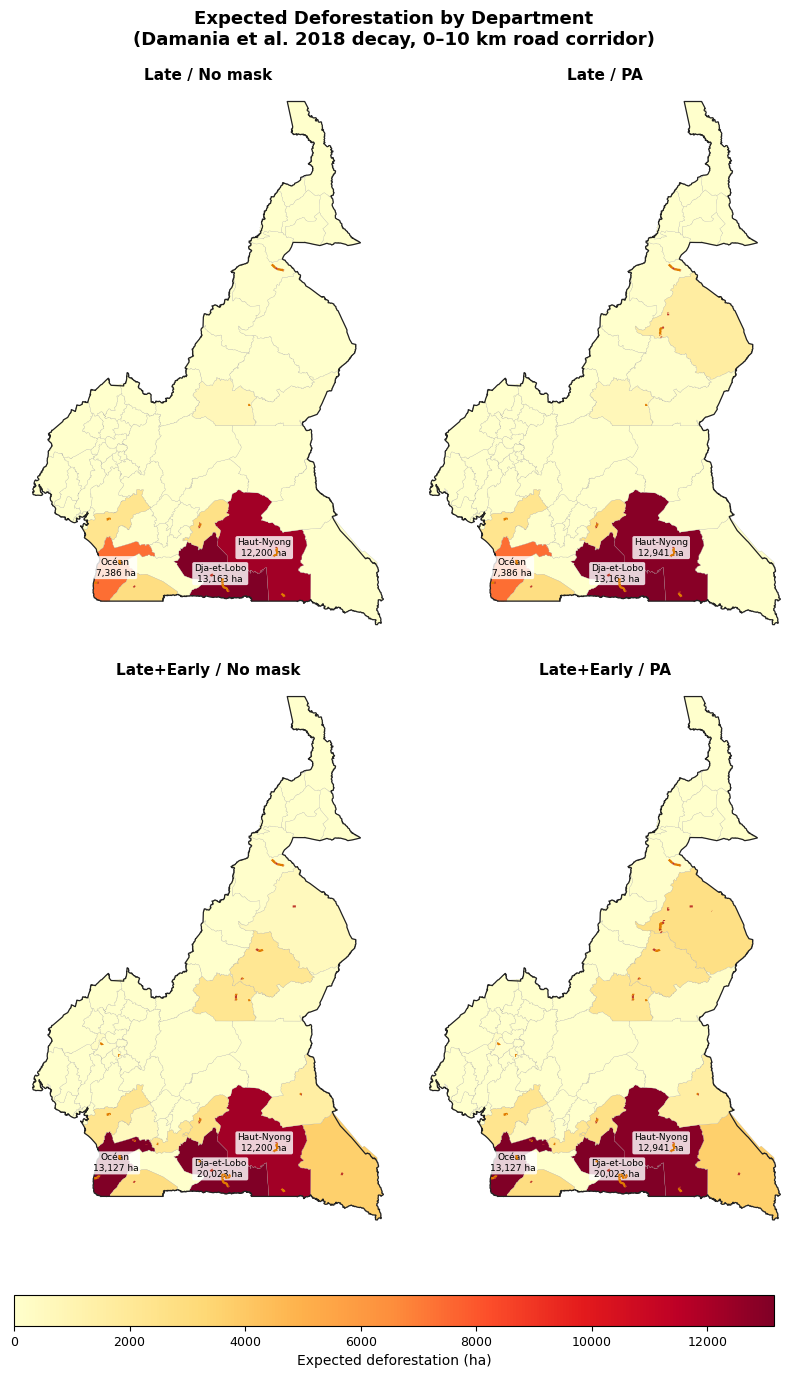

In [77]:
from shapely.geometry import mapping as shapely_mapping

def defor_per_admin2(tif_fp, admin2_gdf):
    """Return array of expected deforestation (ha) per admin2 row from a defor_loss_pct TIF."""
    defor_vals = np.zeros(len(admin2_gdf))

    with rasterio.open(tif_fp) as src:
        res_x = abs(src.transform.a)
        res_y = abs(src.transform.e)
        px_m  = res_x * 111320 * np.cos(np.radians(5.0))
        py_m  = res_y * 110540
        pixel_area_ha = px_m * py_m / 10_000

        raster_crs = src.crs.to_epsg()
        admin_crs  = admin2_gdf.crs.to_epsg() if admin2_gdf.crs else 4326
        if raster_crs and admin_crs and raster_crs != admin_crs:
            gdf_proj = admin2_gdf.to_crs(epsg=raster_crs)
        else:
            gdf_proj = admin2_gdf

        for i, geom in enumerate(gdf_proj.geometry):
            try:
                arr, _ = rio_mask(src, [shapely_mapping(geom)],
                                  crop=True, nodata=0, filled=True)
                vals = arr[0].astype(float)
                defor_vals[i] = np.sum(vals[vals > 0]) / 100.0 * pixel_area_ha
            except Exception:
                defor_vals[i] = 0.0

    return defor_vals

print("Computing admin2 deforestation sums (this may take ~1–2 min)…")
defor_by_scenario = {}
for stem in STEMS:
    tif_fp = BASE_DIR / f"{stem}__defor_loss_pct.tif"
    defor_by_scenario[stem] = defor_per_admin2(tif_fp, cmr2)
    print(f"  {SCENARIO_META[stem]['short']}: total {defor_by_scenario[stem].sum():,.0f} ha")

all_vals = np.concatenate(list(defor_by_scenario.values()))
pos_vals = all_vals[all_vals > 0]
vmax_defor = float(np.percentile(pos_vals, 95)) if len(pos_vals) else 1.0
norm_defor = Normalize(vmin=0, vmax=vmax_defor)
cmap_defor = plt.cm.YlOrRd

fig, axes = plt.subplots(2, 2, figsize=(10, 14))
fig.suptitle(
    "Expected Deforestation by Department\n"
    "(Damania et al. 2018 decay, 0–10 km road corridor)",
    fontsize=13, fontweight="bold",
)
plt.subplots_adjust(bottom=0.10, top=0.93, hspace=0.05, wspace=0.05)

for ax, stem in zip(axes.flat, STEMS):
    meta     = SCENARIO_META[stem]
    plot_gdf = cmr2.copy()
    plot_gdf["defor_ha"] = defor_by_scenario[stem]

    cmr0.plot(ax=ax, color="#f0ede8", edgecolor="none", zorder=1)
    plot_gdf.plot(column="defor_ha", ax=ax,
                  cmap=cmap_defor, norm=norm_defor,
                  edgecolor="#aaa", linewidth=0.15, legend=False, zorder=2)
    cmr0.plot(ax=ax, color="none", edgecolor="#222", linewidth=0.9, zorder=3)

    roads = gpd.read_file(BASE_DIR / f"{stem}__action_roads.gpkg").to_crs("EPSG:4326")
    upgrades  = roads[roads["action_needed"] == "upgrade"]
    new_roads = roads[roads["action_needed"] == "build"]
    if not upgrades.empty:
        upgrades.plot(ax=ax, color="#e07b00", linewidth=1.5, zorder=4)
    if not new_roads.empty:
        new_roads.plot(ax=ax, color="#c0392b", linewidth=1.5, zorder=4)

    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)
    ax.axis("off")
    ax.set_title(meta["short"], fontweight="bold", fontsize=11)

    top3 = plot_gdf.nlargest(3, "defor_ha")
    for _, row in top3.iterrows():
        if row["defor_ha"] > 0:
            cx   = row.geometry.centroid.x
            cy   = row.geometry.centroid.y
            name = str(row.get("adm2_name1", "")).strip()
            ax.annotate(
                f"{name}\n{row['defor_ha']:,.0f} ha",
                xy=(cx, cy), fontsize=6.5, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.82, ec="none"),
            )

# Colorbar in dedicated axes below the grid
sm = ScalarMappable(cmap=cmap_defor, norm=norm_defor)
sm.set_array([])
cax = fig.add_axes([0.12, 0.04, 0.76, 0.022])
cb  = fig.colorbar(sm, cax=cax, orientation="horizontal")
cb.set_label("Expected deforestation (ha)", fontsize=10)
cb.ax.tick_params(labelsize=9)

plt.savefig(FIGURES_DIR / "fig5_deforestation_admin2_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

## 6. Spatial Map — Fragmentation Delta (Admin2 Choropleth)

Per-department change in patch count (action − baseline). Positive = more patches
created (fragmentation); negative = patches merged. Labels mark the 5 most-affected
departments in each scenario.

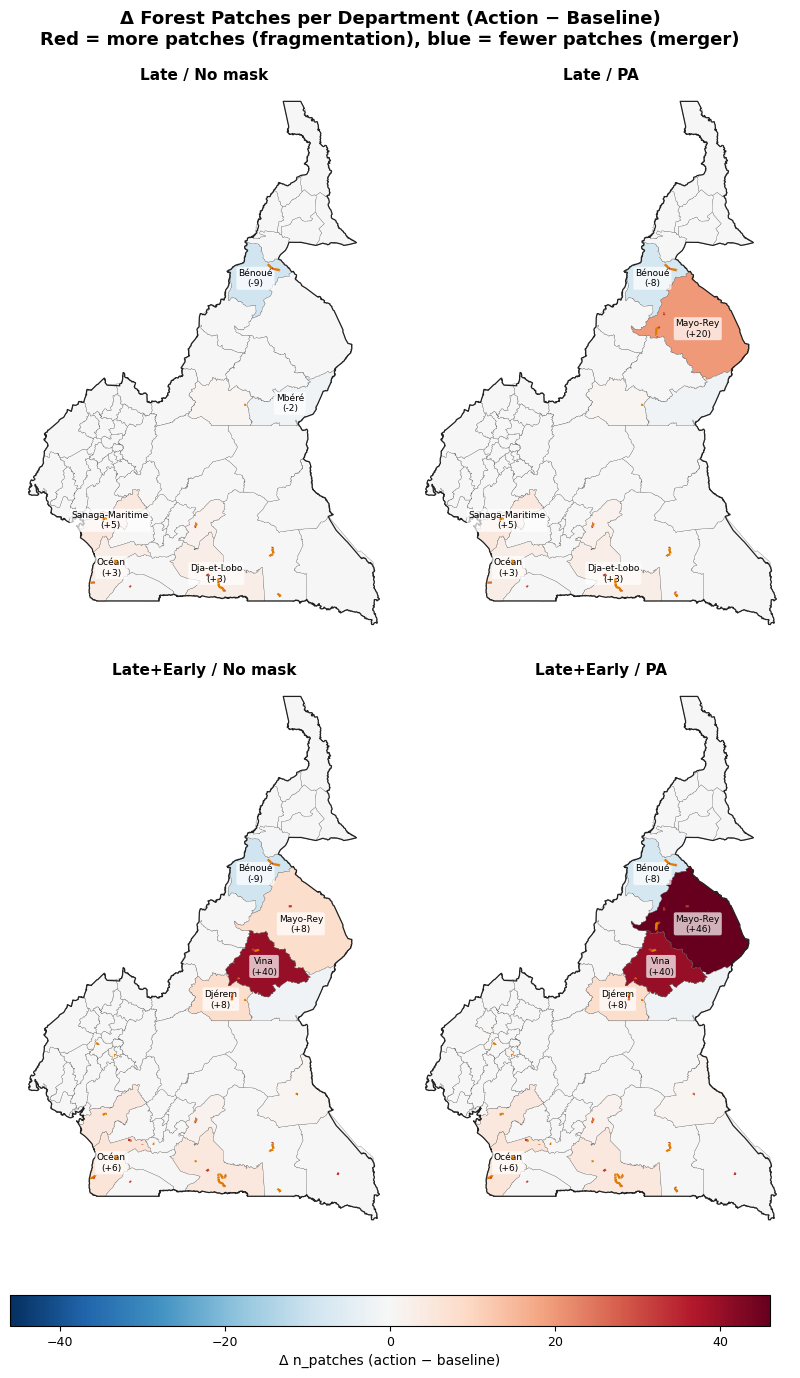

In [78]:
baseline_gdf = (
    gpd.read_file(BASELINE_GPKG)
    .to_crs("EPSG:4326")
    [["adm2_pcode", "n_patches", "geometry"]]
    .rename(columns={"n_patches": "baseline_n_patches"})
)

fig, axes = plt.subplots(2, 2, figsize=(10, 14))
fig.suptitle("Δ Forest Patches per Department (Action − Baseline)\n"
             "Red = more patches (fragmentation), blue = fewer patches (merger)",
             fontsize=13, fontweight="bold")
plt.subplots_adjust(bottom=0.10, top=0.93, hspace=0.05, wspace=0.05)

all_deltas = []
for stem in STEMS:
    gdf_s  = gpd.read_file(BASE_DIR / f"{stem}__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.gpkg")
    merged = baseline_gdf.merge(
        gdf_s[["adm2_pcode", "n_patches"]].rename(columns={"n_patches": "action_n"}),
        on="adm2_pcode", how="left",
    )
    merged["delta_n"] = merged["action_n"] - merged["baseline_n_patches"]
    all_deltas.extend(merged["delta_n"].dropna().tolist())

abs_max   = max(abs(min(all_deltas)), abs(max(all_deltas)), 1)
norm_frag = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
cmap_frag = plt.cm.RdBu_r

for ax, stem in zip(axes.flat, STEMS):
    meta  = SCENARIO_META[stem]
    gdf_s = gpd.read_file(
        BASE_DIR / f"{stem}__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.gpkg"
    ).to_crs("EPSG:4326")

    merged = baseline_gdf.merge(
        gdf_s[["adm2_pcode", "n_patches", "adm2_name1"]].rename(
            columns={"n_patches": "action_n"}
        ),
        on="adm2_pcode", how="left",
    )
    merged["delta_n"] = merged["action_n"] - merged["baseline_n_patches"]

    cmr0.plot(ax=ax, color="#f0ede8", edgecolor="none", zorder=1)
    merged.plot(column="delta_n", ax=ax, cmap=cmap_frag, norm=norm_frag,
                edgecolor="#555", linewidth=0.2, legend=False,
                missing_kwds={"color": "#eee"}, zorder=2)
    cmr0.plot(ax=ax, color="none", edgecolor="#222", linewidth=0.9, zorder=3)

    # Action roads overlay
    roads = gpd.read_file(BASE_DIR / f"{stem}__action_roads.gpkg").to_crs("EPSG:4326")
    upgrades  = roads[roads["action_needed"] == "upgrade"]
    new_roads = roads[roads["action_needed"] == "build"]
    if not upgrades.empty:
        upgrades.plot(ax=ax, color="#e07b00", linewidth=1.5, zorder=4)
    if not new_roads.empty:
        new_roads.plot(ax=ax, color="#c0392b", linewidth=1.5, zorder=4)

    top5 = merged.reindex(merged["delta_n"].abs().nlargest(5).index)
    for _, row in top5.iterrows():
        if pd.notna(row["delta_n"]) and row["delta_n"] != 0:
            cx   = row["geometry"].centroid.x
            cy   = row["geometry"].centroid.y
            name = str(row.get("adm2_name1", "")).strip() or str(row.get("adm2_pcode", ""))
            ax.annotate(f"{name}\n({row['delta_n']:+.0f})", xy=(cx, cy),
                        fontsize=6.5, ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

    ax.set_xlim(x0 - pad, x1 + pad)
    ax.set_ylim(y0 - pad, y1 + pad)
    ax.axis("off")
    ax.set_title(meta["short"], fontweight="bold", fontsize=11)

# Colorbar in dedicated axes below the grid
sm2 = ScalarMappable(cmap=cmap_frag, norm=norm_frag)
sm2.set_array([])
cax2 = fig.add_axes([0.12, 0.04, 0.76, 0.022])
cb2  = fig.colorbar(sm2, cax=cax2, orientation="horizontal")
cb2.set_label("Δ n_patches (action − baseline)", fontsize=10)
cb2.ax.tick_params(labelsize=9)

plt.savefig(FIGURES_DIR / "fig6_fragmentation_delta_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

<p style="color: #1565c0; font-style: italic;">
Add notes
</p>

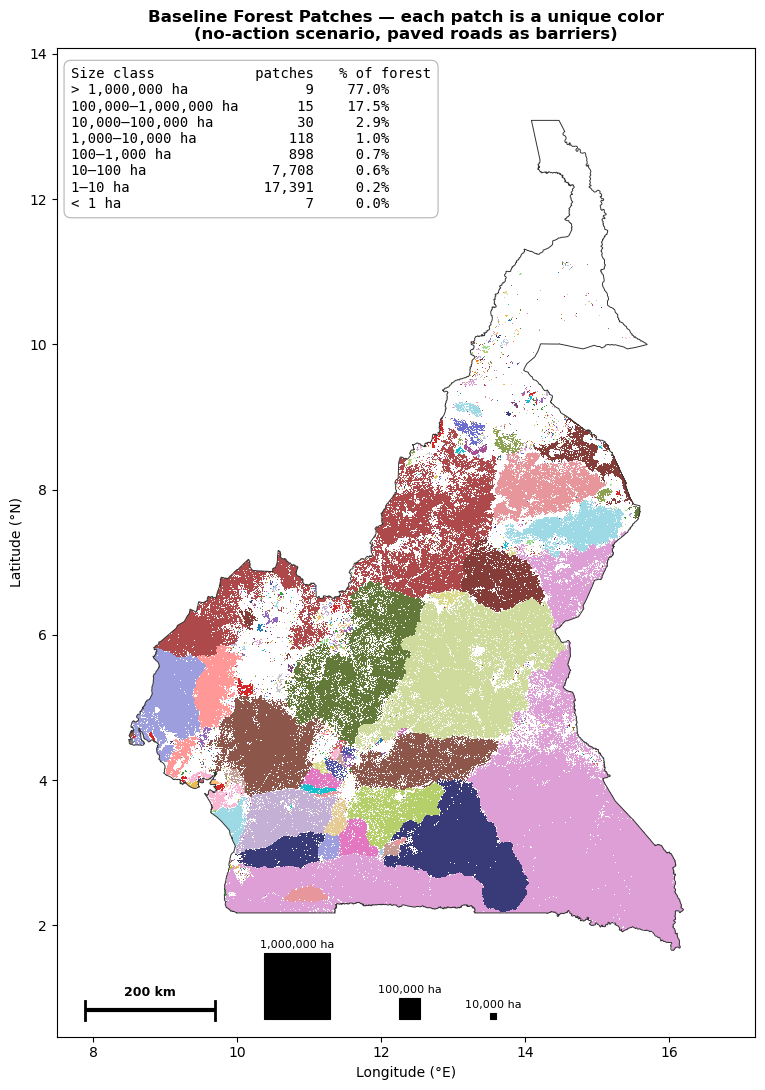

In [79]:
import math
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import tab20, tab20b

# ── Paths / dependencies not present in this notebook ────────────────────────
_BASELINE_TIF = DATA_DIR / "output/forest-patch-detection/no_action__forest_patches__thresh10__minpatch1ha__adm2__roads_paved.tif"

SIZE_BINS_BL = [
    ("> 1,000,000 ha",         lambda h: h > 1_000_000),
    ("100,000–1,000,000 ha",   lambda h: (h >= 100_000) & (h <= 1_000_000)),
    ("10,000–100,000 ha",      lambda h: (h >= 10_000)  & (h <  100_000)),
    ("1,000–10,000 ha",        lambda h: (h >= 1_000)   & (h <  10_000)),
    ("100–1,000 ha",           lambda h: (h >= 100)     & (h <  1_000)),
    ("10–100 ha",              lambda h: (h >= 10)      & (h <  100)),
    ("1–10 ha",                lambda h: (h >= 1)       & (h <  10)),
    ("< 1 ha",                 lambda h:  h < 1),
]

with rasterio.open(_BASELINE_TIF) as _src:
    _tf     = _src.transform
    _lat_c  = _tf.f + (_src.height / 2) * _tf.e
    _pix_w  = abs(_tf.a) * 111_320 * np.cos(np.radians(_lat_c))
    _pix_h  = abs(_tf.e) * 111_320
    _pix_ha = (_pix_w * _pix_h) / 10_000
    _, _px_counts = np.unique(_src.read(1)[_src.read(1) > 0], return_counts=True)

patch_ha_bl = _px_counts * _pix_ha
rows_bl = []
for label, cond in SIZE_BINS_BL:
    mask = cond(patch_ha_bl)
    rows_bl.append({
        "Size class":        label,
        "Patch count":       int(mask.sum()),
        "Total area (ha)":   float(patch_ha_bl[mask].sum()),
        "% of patches":      100 * mask.sum() / len(patch_ha_bl),
        "% of forest area":  100 * patch_ha_bl[mask].sum() / patch_ha_bl.sum(),
    })
size_df = pd.DataFrame(rows_bl)

# ── Load patch-ID raster ──────────────────────────────────────────────────────
with rasterio.open(_BASELINE_TIF) as src:
    id_arr   = src.read(1)
    size_ext = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# ── Assign a random color index (1–40) to each patch ─────────────────────────
N_COLORS   = 40
rng        = np.random.default_rng(42)
patch_ids  = np.unique(id_arr[id_arr > 0])
cidx_vals  = rng.integers(1, N_COLORS + 1, size=len(patch_ids)).astype(np.uint8)
id_to_cidx = np.zeros(int(patch_ids.max()) + 1, dtype=np.uint8)
id_to_cidx[patch_ids] = cidx_vals

STEP      = 3
cidx_disp = id_to_cidx[id_arr[::STEP, ::STEP]]

_qcols      = list(tab20.colors) + list(tab20b.colors)
cmap_unique = ListedColormap(["white"] + _qcols[:N_COLORS])
norm_unique = BoundaryNorm(np.arange(-0.5, N_COLORS + 1.5), ncolors=N_COLORS + 1)

map_xmin, map_xmax = size_ext[0], size_ext[1]
map_ymin, map_ymax = size_ext[2], size_ext[3]
map_w = map_xmax - map_xmin
map_h = map_ymax - map_ymin

# ── Layout constants ──────────────────────────────────────────────────────────
lat_c      = (map_ymin + map_ymax) / 2
km_per_deg = 111.32 * math.cos(math.radians(lat_c))

label_gap = map_h * 0.003
tick_h    = map_h * 0.010

country_south = cmr0.total_bounds[1]   # was cmr0_wgs
max_sq_deg    = math.sqrt(1_000_000 / 100) / km_per_deg
y_bottom      = country_south - max_sq_deg - label_gap
y_axis_min    = y_bottom - label_gap * 6

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 11))

ax.imshow(cidx_disp, cmap=cmap_unique, norm=norm_unique,
          extent=size_ext, origin="upper", interpolation="nearest", zorder=0)
cmr0.plot(ax=ax, color="none", edgecolor="#333333", linewidth=0.7, zorder=1)
ax.set_xlim(map_xmin, map_xmax)
ax.set_ylim(y_axis_min, map_ymax)
ax.set_title(
    "Baseline Forest Patches — each patch is a unique color\n"
    "(no-action scenario, paved roads as barriers)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

# ── Scale bar (sb_ prefix avoids shadowing global x0, x1) ────────────────────
scale_km  = 200
scale_deg = scale_km / km_per_deg
bar_h     = map_h * 0.018
sb_x0 = map_xmin + map_w * 0.04
sb_x1 = sb_x0 + scale_deg
y_bar = y_bottom + bar_h / 2

ax.plot([sb_x0, sb_x1], [y_bar, y_bar], color="black", linewidth=3,
        solid_capstyle="butt", zorder=5)
for _xt in [sb_x0, sb_x1]:
    ax.plot([_xt, _xt], [y_bar - tick_h, y_bar + tick_h],
            color="black", linewidth=2, zorder=5)
ax.text((sb_x0 + sb_x1) / 2, y_bottom + bar_h + label_gap,
        f"{scale_km} km", ha="center", va="bottom",
        fontsize=9, fontweight="bold", zorder=5)

# ── Reference squares ─────────────────────────────────────────────────────────
gap_between = map_w * 0.1
cursor_x    = sb_x1 + map_w * 0.07

for sq_ha, sq_label in [
    (1_000_000, "1,000,000 ha"),
    (  100_000,   "100,000 ha"),
    (   10_000,    "10,000 ha"),
]:
    sq_km  = math.sqrt(sq_ha / 100)
    sq_deg = sq_km / km_per_deg

    ax.add_patch(plt.Rectangle(
        (cursor_x, y_bottom), sq_deg, sq_deg,
        facecolor="black", edgecolor="black", linewidth=0.8, zorder=5,
    ))
    ax.text(cursor_x + sq_deg / 2, y_bottom + sq_deg + label_gap,
            sq_label, ha="center", va="bottom", fontsize=8, zorder=5)

    cursor_x += sq_deg + gap_between

# ── Stats text box ────────────────────────────────────────────────────────────
BIN_LABELS_LS = ["> 1,000,000 ha", "100,000–1,000,000 ha", "10,000–100,000 ha",
                 "1,000–10,000 ha", "100–1,000 ha", "10–100 ha", "1–10 ha", "< 1 ha"]

lines = ["Size class            patches   % of forest"]
for i, label in enumerate(BIN_LABELS_LS):
    _row = size_df.iloc[i]
    lines.append(f"{label:<20s}  {int(_row['Patch count']):>7,}   {_row['% of forest area']:>5.1f}%")

ax.text(
    map_xmin + map_w * 0.02,
    map_ymax - map_h * 0.02,
    "\n".join(lines),
    va="top", ha="left", fontsize=10,
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.88,
              edgecolor="#aaaaaa", linewidth=0.8),
    zorder=6,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig0c_baseline_patch_map.png", dpi=150, bbox_inches="tight")
plt.show()